Task 1: Data Loading and Understanding

1.1 Load each dataset and display its structure

In [ ]:
# Session Notes
# we can exclude stateTxn_Users sheet as distTxn_Users sheet has same data at more granular level
# This was concluded based on the analysis done on the 2 excel sheets provided i.e when we do pivot on distTxn_Users
# it matches with the data in stateTxn_Users
# Doubt: the column ATV(INR) value after pivoting distTxn_Users dont exactly match the ATV(INR) column in stateTxn_Users

In [2]:
import pandas as pd

In [3]:
# stateTxn_Users = pd.read_excel("C:/Users/vaishnavi/Downloads/phonepe-pulse_raw-data.xlsx", sheet_name = "State_Txn and Users")
# stateTxn_Split = pd.read_excel("C:/Users/vaishnavi/Downloads/phonepe-pulse_raw-data.xlsx", sheet_name = "State_TxnSplit")
# stateTxn_DevData = pd.read_excel("C:/Users/vaishnavi/Downloads/phonepe-pulse_raw-data.xlsx", sheet_name = "State_DeviceData")
# distTxn_Users = pd.read_excel("C:/Users/vaishnavi/Downloads/phonepe-pulse_raw-data.xlsx", sheet_name = "District_Txn and Users")
# distDemo = pd.read_excel("C:/Users/vaishnavi/Downloads/phonepe-pulse_raw-data.xlsx", sheet_name = "District Demographics")

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/vaishnavi/Downloads/phonepe-pulse_raw-data.xlsx'

In [3]:
stateTxn_Users = pd.read_excel("/content/sample_data/phonepe-pulse_raw-data.xlsx", sheet_name = "State_Txn and Users")
stateTxn_Split = pd.read_excel("/content/sample_data/phonepe-pulse_raw-data.xlsx", sheet_name = "State_TxnSplit")
stateTxn_DevData = pd.read_excel("/content/sample_data/phonepe-pulse_raw-data.xlsx", sheet_name = "State_DeviceData")
distTxn_Users = pd.read_excel("/content/sample_data/phonepe-pulse_raw-data.xlsx", sheet_name = "District_Txn and Users")
distDemo = pd.read_excel("/content/sample_data/phonepe-pulse_raw-data.xlsx", sheet_name = "District Demographics")

In [ ]:
stateTxn_Users.head()
stateTxn_Split.tail(10)
mid = len(stateTxn_DevData)//2
# print(mid)
stateTxn_DevData.iloc[mid-4:mid+6]
distTxn_Users.head(10)
distTxn_Users.tail(10)
distDemo.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


1.2 Display basic statistics and datatype for each dataset

In [ ]:
# stateTxn_Users_num_cols = stateTxn_Users.select_dtypes(include = 'number').drop(columns = ['Year','Quarter'])
# stateTxn_Users_num_cols.describe()
# stateTxn_Split_num_cols = stateTxn_Split.select_dtypes(include = 'number').drop(columns = ['Year','Quarter'])
# stateTxn_Split_num_cols.describe()
# stateTxn_DevData_num_cols = stateTxn_DevData.select_dtypes(include = 'number').drop(columns = ['Year','Quarter'])
# stateTxn_DevData_num_cols.describe()
# distTxn_Users_num_cols = distTxn_Users.select_dtypes(include = 'number').drop(columns = ['Year','Quarter'])
# distTxn_Users_num_cols.describe()
# distDemo_num_cols = distDemo.select_dtypes(include = 'number')
# distDemo_num_cols.describe()

In [8]:
# stateTxn_Users.dtypes
# stateTxn_Split.dtypes
# stateTxn_DevData.dtypes
# distTxn_Users.dtypes
# distDemo.dtypes

1.3 Check for missing values

In [11]:
# stateTxn_Users.info()
# stateTxn_Users.isnull().sum()    # Amount (INR) = 1
# stateTxn_Split.isnull().sum()    # no nulls
# stateTxn_DevData.isnull().sum()  # no nulls
# distTxn_Users.isnull().sum()       # Code = 28, ATV (INR) = 4
# distDemo.isnull().sum()            # no nulls

In [ ]:
per_of_missing_values1 = (stateTxn_Users['Amount (INR)'].isnull().sum()/stateTxn_Users['Amount (INR)'].shape[0])*100
print(per_of_missing_values1)
per_of_missing_values2 = (distTxn_Users['Code'].isnull().sum()/distTxn_Users['Code'].shape[0])*100
print(per_of_missing_values2)
per_of_missing_values3 = (distTxn_Users['ATV (INR)'].isnull().sum()/distTxn_Users['ATV (INR)'].shape[0])*100
print(per_of_missing_values3)

0.1984126984126984
0.273224043715847
0.039032006245121


1.4 Create Summary

In [12]:
# num_of_states = len(distTxn_Users['State'].unique())
#or
num_of_states = distTxn_Users['State'].nunique()
print("Num of States: ",num_of_states)
num_of_dists = distTxn_Users['District'].nunique()
print("Num of Districts: ",num_of_dists)

Num of States:  36
Num of Districts:  723


In [15]:
# distTxn_Users['State'].value_counts()
distTxn_Users['State'].value_counts().idxmax()

'Uttar Pradesh'

Task 2: Exploratory Data Analysis (EDA)

2.1 Analyze transaction trends over the years for each state

In [19]:
tran_trends_by_state = distTxn_Users.groupby('State').agg({'Transactions':'sum','Amount (INR)':'sum'}).reset_index().sort_values(by ='Transactions', ascending = False)
# tran_trends_by_state = distTxn_Users.groupby('State').agg({'Transactions':'sum','Amount (INR)':'sum'}).reset_index().sort_values(by ='Amount (INR)', ascending = False)

In [ ]:
# Highest num of transactions is of Karnataka and Highest total transaction amount is of Telangana

In [20]:
# Top 5 states with highest transaction volumn
tran_trends_by_state.head()

,State,Transactions,Amount (INR)
15,Karnataka,2981044533,4.361396e+12
20,Maharashtra,2833670154,4.290995e+12
31,Telangana,2347430243,4.574246e+12
1,Andhra Pradesh,1781091169,3.860292e+12
28,Rajasthan,1382918930,2.625584e+12


In [21]:
# Top 5 states with lowest transaction volumn
tran_trends_by_state.tail()

,State,Transactions,Amount (INR)
22,Meghalaya,5648913,1.254162e+10
23,Mizoram,2162776,6.317141e+09
17,Ladakh,1880109,6.606978e+09
0,Andaman & Nicobar Islands,1223565,3.641818e+09
18,Lakshadweep,71610,1.921587e+08


2.2 Identify the most common transaction types in each state and quarter

In [ ]:
stateTxn_Split.shape

(2514, 7)

In [3]:
groupedDf = stateTxn_Split.groupby(['State','Year','Quarter','Transaction Type'])['Transactions'].sum().reset_index()

In [13]:
groupedDf.head(5)
# groupedDf.shape

,State,Year,Quarter,Transaction Type,Transactions
0,Andaman & Nicobar Islands,2018,1,Financial Services,33
1,Andaman & Nicobar Islands,2018,1,Merchant payments,298
2,Andaman & Nicobar Islands,2018,1,Others,256
3,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871
4,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200


In [9]:
# sorted_groupedDf = groupedDf.sort_values(by=['State', 'Year', 'Quarter', 'Transactions'], ascending=[True, True, True, False])
# display(sorted_groupedDf.head())

,State,Year,Quarter,Transaction Type,Transactions
4,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200
3,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871
1,Andaman & Nicobar Islands,2018,1,Merchant payments,298
2,Andaman & Nicobar Islands,2018,1,Others,256
0,Andaman & Nicobar Islands,2018,1,Financial Services,33


In [5]:
idx = groupedDf.groupby(['State','Year','Quarter'])['Transactions'].idxmax()
# print(idx)
most_common = groupedDf.loc[idx]
print(most_common.head())
# print(most_common[(most_common['Year']==2021) & (most_common['Quarter']==2)])

                        State  Year  Quarter          Transaction Type  \
4   Andaman & Nicobar Islands  2018        1  Recharge & bill payments   
9   Andaman & Nicobar Islands  2018        2  Recharge & bill payments   
14  Andaman & Nicobar Islands  2018        3  Recharge & bill payments   
19  Andaman & Nicobar Islands  2018        4  Recharge & bill payments   
24  Andaman & Nicobar Islands  2019        1  Recharge & bill payments   

    Transactions  
4           4200  
9           6735  
14          8636  
19         11517  
24         15263  


In [14]:
# sorted_groupedDf.groupby(['State','Year','Quarter'])['Transactions'].idxmax()

np.int64(1111)

In [20]:
# sorted_groupedDf.iloc[1111]

2.3 Device brand with the highest number of registered users in each state

In [ ]:
groupedDf2_3 = stateTxn_DevData.groupby(['State','Brand'])['Registered Users'].sum().reset_index()
groupedDf2_3.head(12)

,State,Brand,Registered Users
0,Andaman & Nicobar Islands,Apple,9334
1,Andaman & Nicobar Islands,Huawei,11497
2,Andaman & Nicobar Islands,Lenovo,5362
3,Andaman & Nicobar Islands,Motorola,9491
4,Andaman & Nicobar Islands,OnePlus,15397
5,Andaman & Nicobar Islands,Oppo,36007
6,Andaman & Nicobar Islands,Others,33630
7,Andaman & Nicobar Islands,Realme,22546
8,Andaman & Nicobar Islands,Samsung,77065
9,Andaman & Nicobar Islands,Tecno,1770


In [ ]:
idx2_3 = groupedDf2_3.groupby(['State'])['Registered Users'].idxmax()
result_2_3 = groupedDf2_3.loc[idx2_3]
print(result_2_3.head())

                        State   Brand  Registered Users
11  Andaman & Nicobar Islands  Xiaomi             97889
22             Andhra Pradesh  Xiaomi          40061549
34          Arunachal Pradesh  Xiaomi            437803
46                      Assam  Xiaomi           6979357
60                      Bihar  Xiaomi          33721314


2.4 List of top districts per state based on population

In [ ]:
distDemo.columns

Index(['State', 'District', 'Headquarters', 'Population', 'Area (sq km)',
       'Density', 'Code', 'Alternate Name'],
      dtype='object')

In [21]:
groupedDf2_4 = distDemo.groupby(['State','District'])['Population'].sum().reset_index()
# print(groupedDf2_4)
idx2_4 = groupedDf2_4.groupby(['State'])['Population'].idxmax()
# print(idx2_4)
result2_4 = groupedDf2_4.loc[idx2_4].sort_values(by = 'Population', ascending=False)
print(result2_4)

                                    State                District  Population
734                           West Bengal       North 24 Parganas    10082852
272                             Karnataka         Bangalore Urban     9588910
397                           Maharashtra                    Pune     9426959
158                               Gujarat               Ahmedabad     7208200
554                            Tamil Nadu                 Chennai     7139882
530                             Rajasthan                  Jaipur     6663971
633                         Uttar Pradesh               Allahabad     5959798
100                                 Bihar                   Patna     5772804
5                          Andhra Pradesh           East Godavari     5151549
308                                Kerala              Malappuram     4110956
592                             Telangana               Hyderabad     3943323
150                                 Delhi        North West Delh

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

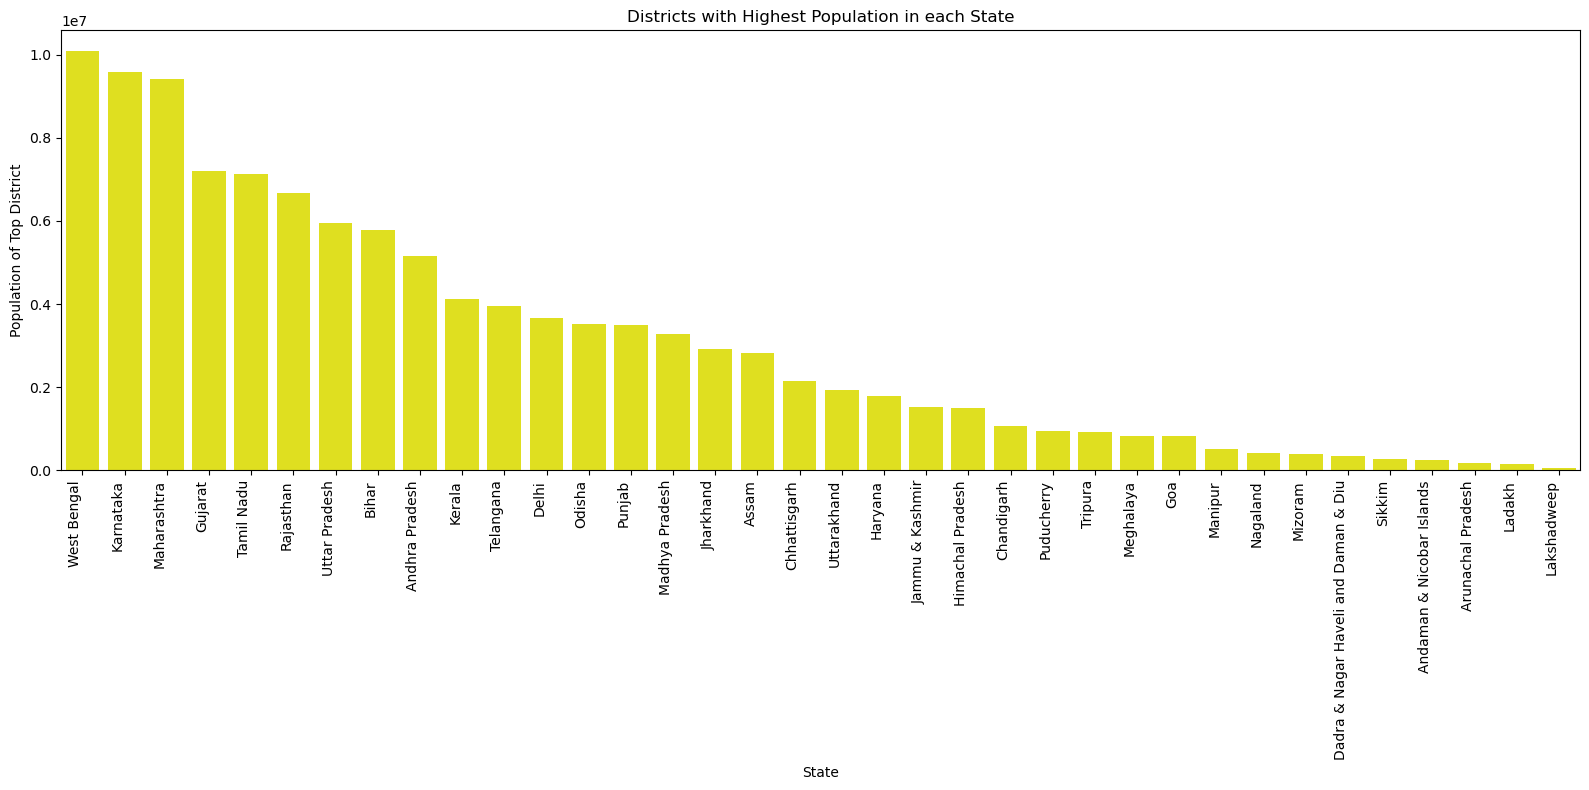

In [ ]:
plt.figure(figsize = (16,8))
barplt = sns.barplot(data = result2_4, x='State', y='Population', color='yellow')
# for i, row in result2_4.iterrows():
#     barplt.text(i, row['Population'], row['District'], ha='center', va='bottom', fontsize=8, rotation=90)
plt.title('Districts with Highest Population in each State')
plt.xlabel('State')
plt.ylabel('Population of Top District')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

2.5 Average Transaction Value (ATV) for each state

In [ ]:
distTxn_Users.head(5)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0


In [ ]:
top5_states_with_highATV = distTxn_Users.groupby('State')['ATV (INR)'].mean().reset_index().sort_values(by='ATV (INR)', ascending = False).head(5)
print("Top 5 States with highest ATV")
print(top5_states_with_highATV)
top5_states_with_lowATV = distTxn_Users.groupby('State')['ATV (INR)'].mean().reset_index().sort_values(by = 'ATV (INR)').head(5)
print("Top 5 States with lowest ATV")
print(top5_states_with_lowATV)

Top 5 States with highest ATV
                        State    ATV (INR)
17                     Ladakh  3391.265233
0   Andaman & Nicobar Islands  3273.392542
23                    Mizoram  3010.327017
18                Lakshadweep  2776.118701
2           Arunachal Pradesh  2678.605340
Top 5 States with lowest ATV
          State    ATV (INR)
35  West Bengal  1377.639842
32      Tripura  1548.465799
8         Delhi  1569.462534
20  Maharashtra  1589.759225
25       Odisha  1593.026649


2.6 Analyze app usage trends

In [6]:
distTxn_Users_mod = distTxn_Users
# distTxn_Users_mod.dtypes
distTxn_Users_mod['Year-Quarter'] = distTxn_Users_mod['Year'].astype(str)+"-Q"+distTxn_Users_mod['Quarter'].astype(str)
# distTxn_Users_mod
data2_6 = distTxn_Users.groupby(['State','Year-Quarter'])['App Opens'].sum().reset_index()
print(data2_6[data2_6['State']=='Maharashtra'])

           State Year-Quarter   App Opens
280  Maharashtra      2018-Q1           0
281  Maharashtra      2018-Q2           0
282  Maharashtra      2018-Q3           0
283  Maharashtra      2018-Q4           0
284  Maharashtra      2019-Q1           0
285  Maharashtra      2019-Q2   109967705
286  Maharashtra      2019-Q3   439998413
287  Maharashtra      2019-Q4   543654112
288  Maharashtra      2020-Q1   615146568
289  Maharashtra      2020-Q2   506354812
290  Maharashtra      2020-Q3   668197101
291  Maharashtra      2020-Q4   952006770
292  Maharashtra      2021-Q1  1101976484
293  Maharashtra      2021-Q2  1208083592


In [9]:
import matplotlib.ticker as ticker

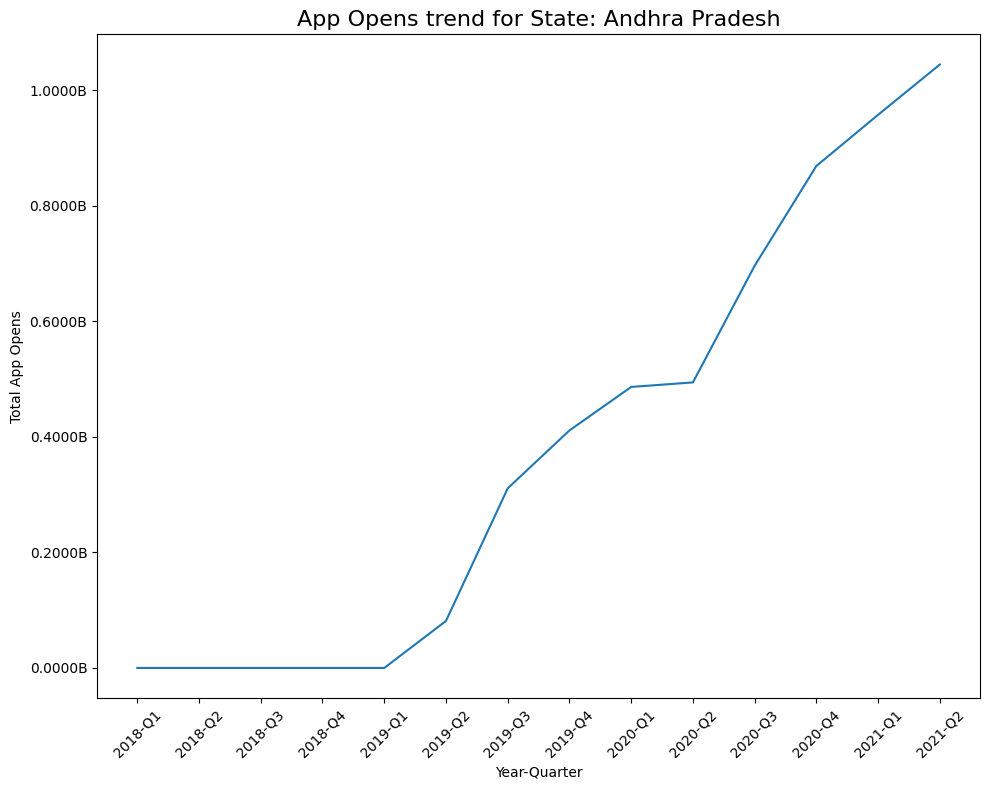

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
selectedState = 'Andhra Pradesh'
ax = sns.lineplot(data = data2_6.loc[data2_6['State'] == selectedState,:], x='Year-Quarter', y='App Opens')

# 1. Define the custom formatter function
def billion_formatter(x, pos):
    """The function returns a string with 'B' suffix for billions."""
    return f'{x / 1e9:.4f}B' # Divides by 1 billion (1e9) and formats to 4 decimal places

# 2. Apply the formatter to the y-axis
formatter = ticker.FuncFormatter(billion_formatter)
ax.yaxis.set_major_formatter(formatter)

plt.title(f'App Opens trend for State: {selectedState}',fontsize=16)
plt.xlabel("Year-Quarter")
plt.ylabel("Total App Opens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2.7 Distribution of transaction types

In [ ]:
stateTxn_Split.head(2)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,6487.790112


In [35]:
sorted_by_yr_n_quarter = stateTxn_Split.sort_values(by = ['Year', 'Quarter'], ascending = [False, False])

In [36]:
latest_year = sorted_by_yr_n_quarter['Year'].iloc[0]
latest_quarter = sorted_by_yr_n_quarter['Quarter'].iloc[0]
print(latest_year)
print(latest_quarter)

2021
2


In [37]:
df_recent_quarter = stateTxn_Split[(stateTxn_Split['Year'] == latest_year) & (stateTxn_Split['Quarter'] == latest_quarter)]
print(df_recent_quarter)

                          State  Year  Quarter          Transaction Type  \
65    Andaman & Nicobar Islands  2021        2     Peer-to-peer payments   
66    Andaman & Nicobar Islands  2021        2  Recharge & bill payments   
67    Andaman & Nicobar Islands  2021        2         Merchant payments   
68    Andaman & Nicobar Islands  2021        2        Financial Services   
69    Andaman & Nicobar Islands  2021        2                    Others   
...                         ...   ...      ...                       ...   
2509                West Bengal  2021        2     Peer-to-peer payments   
2510                West Bengal  2021        2         Merchant payments   
2511                West Bengal  2021        2  Recharge & bill payments   
2512                West Bengal  2021        2        Financial Services   
2513                West Bengal  2021        2                    Others   

      Transactions  Amount (INR)    ATV (INR)  
65          132772  7.483820e+08  5636.

In [ ]:
pivot_data2_7 = df_recent_quarter.pivot_table(index='State',columns='Transaction Type',aggfunc='sum', values='Transactions')

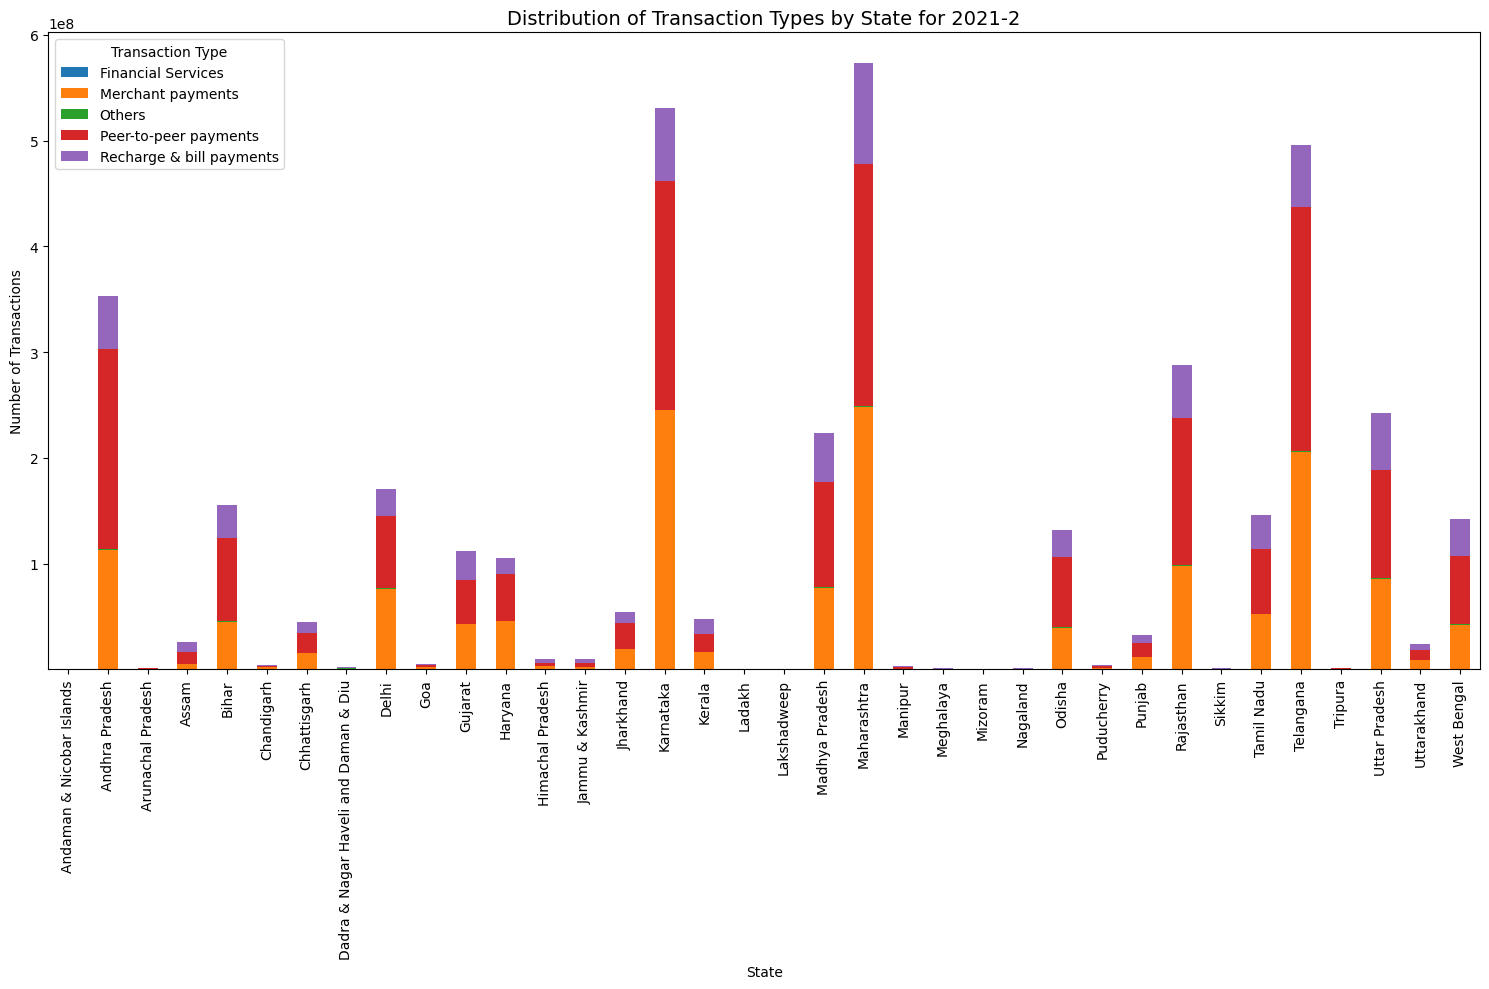

In [ ]:
pivot_data2_7.plot(kind='bar',stacked=True,figsize=(15,10))
plt.ylabel('Number of Transactions')
plt.title(f'Distribution of Transaction Types by State for {latest_year}-{latest_quarter}', fontsize=14)
plt.legend(title='Transaction Type')
plt.tight_layout()
plt.show()

2.8 Unique mapping between district name and district code

In [39]:
distDemo.shape
dist_code_mapping = distDemo[['District','Code']].drop_duplicates()
print(dist_code_mapping.shape)
dist_code_mapping.to_csv('dist_code_mapping.csv', index=False)

(742, 2)


In [ ]:
distDemo.shape

(742, 8)

Task 3: Data Quality Checks
3.1 Ensure data consistency accross state and district levels

In [40]:
agg_df = distTxn_Users.groupby(['State','Year','Quarter']).agg({'Transactions':'sum','Amount (INR)':'sum','ATV (INR)':'mean','Registered Users':'sum','App Opens':'sum'}).reset_index()
agg_df.head(5)
# agg_df.shape

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2158.280308,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2296.565847,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3813.107872,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,4101.175493,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3653.455100,18596,0


In [ ]:
stateTxn_Users.head(5)
# stateTxn_Users.shape

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [42]:
# agg_df.equals(stateTxn_Users)
agg_df.compare(stateTxn_Users)

State       Transactions        Amount (INR)                  ATV (INR)  \
     self other         self other          self         other         self   
0     NaN   NaN          NaN   NaN  1.463176e+07  1.463176e+07  2158.280308   
1     NaN   NaN          NaN   NaN  2.833854e+07  2.833854e+07  2296.565847   
2     NaN   NaN          NaN   NaN  5.555747e+07  5.555747e+07  3813.107872   
3     NaN   NaN          NaN   NaN  9.054834e+07  9.054834e+07  4101.175493   
4     NaN   NaN          NaN   NaN           NaN           NaN  3653.455100   
..    ...   ...          ...   ...           ...           ...          ...   
499   NaN   NaN          NaN   NaN  1.000994e+11  1.000994e+11  1654.109115   
500   NaN   NaN          NaN   NaN  1.568134e+11  1.568134e+11  1857.519436   
501   NaN   NaN          NaN   NaN  1.991655e+11  1.991655e+11  1960.828312   
502   NaN   NaN          NaN   NaN  2.429372e+11  2.429372e+11  2117.690064   
503   NaN   NaN          NaN   NaN  2.794348e+11  2.794348e+11  2002.025545   

                 Registered Users       App Opens        
           other             self other      self other  
0    2197.621091              NaN   NaN       NaN   NaN  
1    2498.989022              NaN   NaN       NaN   NaN  
2    3415.768284              NaN   NaN       NaN   NaN  
3    3811.277720              NaN   NaN       NaN   NaN  
4    3355.630147              NaN   NaN       NaN   NaN  
..           ...              ...   ...       ...   ...  
499  1735.523418              NaN   NaN       NaN   NaN  
500  1961.282329              NaN   NaN       NaN   NaN  
501  1984.893473              NaN   NaN       NaN   NaN  
502  2054.366877              NaN   NaN       NaN   NaN  
503  1969.273138              NaN   NaN       NaN   NaN  

[504 rows x 12 columns]

Conclusion: There are minor changes in values for column Amount (INR), however the value for AVT (INR) have some discrepancies

Task 4: Data Merging and Advanced Analysis

4.1 Ratio of users to population by state

In [ ]:
stateTxn_Users.head(2)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0


In [15]:
stateRegUsers = stateTxn_Users.groupby('State')['Registered Users'].sum().reset_index().sort_values(by = 'Registered Users', ascending = False)
print(stateRegUsers.head())
print(stateRegUsers.shape)

             State  Registered Users
20     Maharashtra         315783658
33   Uttar Pradesh         246200404
15       Karnataka         203098564
1   Andhra Pradesh         158007957
28       Rajasthan         149770064
(36, 2)


In [ ]:
distDemo.head(2)

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
1,Andhra Pradesh,Chittoor,Chittoor,4170468,15152.0,275,AP02,Chittoor


In [16]:
stateDemo = distDemo.groupby('State')['Population'].sum().reset_index().sort_values(by = 'Population', ascending = False)
print(stateDemo.head())

            State  Population
33  Uttar Pradesh   205867440
20    Maharashtra   112378989
4           Bihar   103817951
35    West Bengal    92828987
30     Tamil Nadu    76018492


In [13]:
# stateDemo.shape

In [17]:
merged_df4_1 = pd.merge(stateRegUsers,stateDemo,how='inner',on='State')
# print(merged_df4_1)

In [18]:
merged_df4_1['Ratio']=merged_df4_1['Registered Users']/merged_df4_1['Population']

In [21]:
merged_df4_1.sort_values(by='Ratio',ascending=False, inplace=True)
# merged_df4_1.reset_index(drop=True, inplace=True)
print(merged_df4_1.head())

                                   State  Registered Users  Population  \
11                                 Delhi          95374654    16787941   
26  Dadra & Nagar Haveli and Daman & Diu           2701112      586956   
5                              Telangana         149224214    36366570   
23                            Chandigarh           3801466     1055450   
2                              Karnataka         203098564    60965960   

       Ratio  
11  5.681141  
26  4.601899  
5   4.103335  
23  3.601749  
2   3.331344  


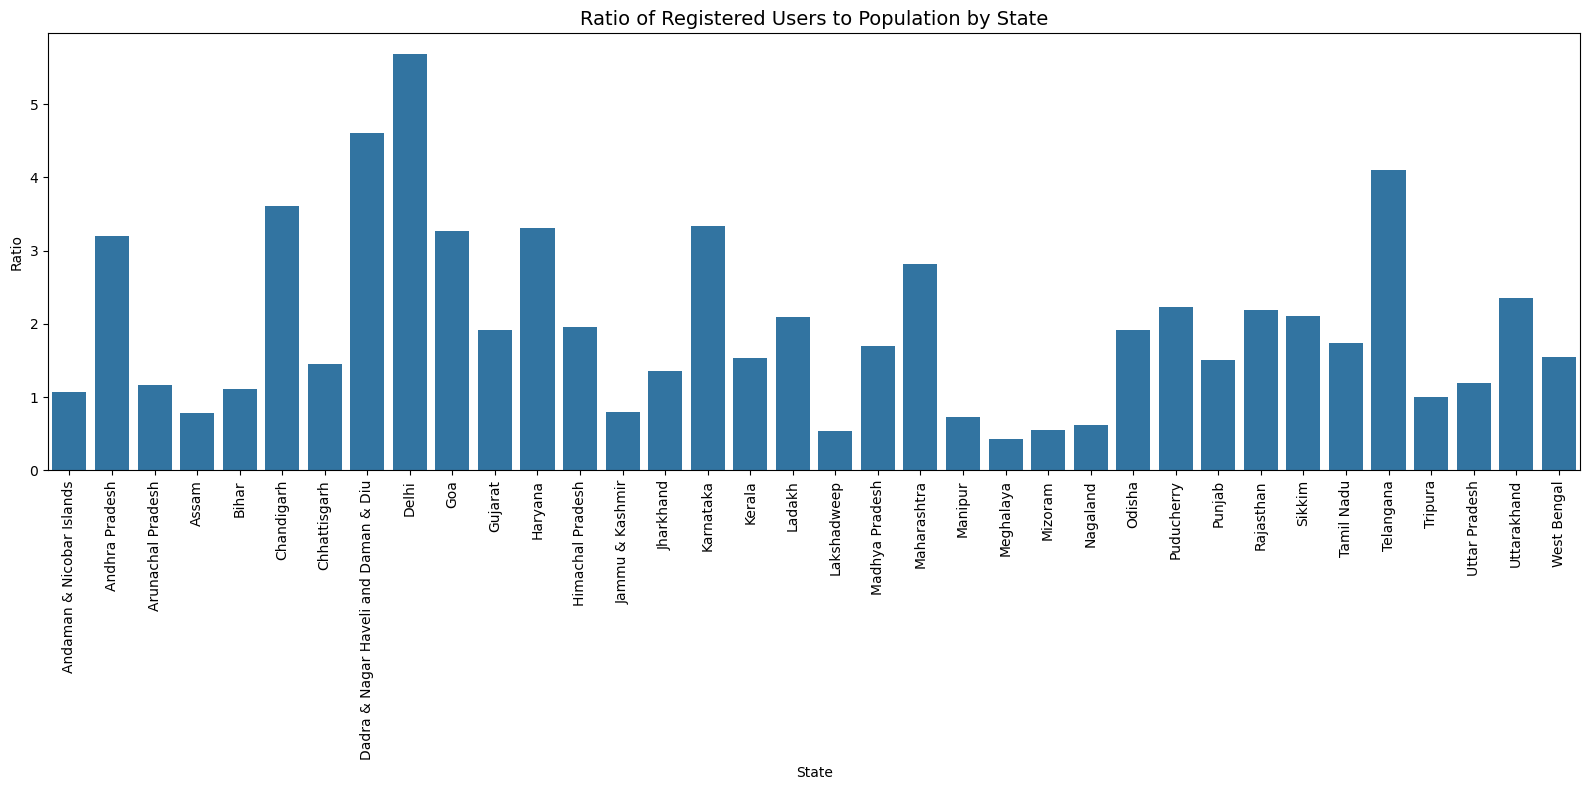

In [ ]:
plt.figure(figsize=(16,8))
sns.barplot(data=merged_df4_1,x='State',y='Ratio')
plt.xlabel('State')
plt.ylabel('Ratio')
plt.title('Ratio of Registered Users to Population by State', fontsize = 14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

4.2 Correlate population density with transaction volumn

In [ ]:
distTxn_Users.shape

(10248, 11)

In [5]:
distDemo.shape

(742, 8)

In [30]:
distTxn_Demo = pd.merge(distTxn_Users,distDemo,how='left',on='Code')

In [ ]:
distTxn_Demo.shape

(10248, 18)

In [31]:
distTxn_Demo.rename(columns = {'State_x':'State', 'District_x': 'District'}, inplace=True)
distTxn_Demo.drop(columns=['State_y','District_y'], inplace= True)
distTxn_Demo.columns

Index(['State', 'Year', 'Quarter', 'District', 'Code', 'Transactions',
       'Amount (INR)', 'ATV (INR)', 'Registered Users', 'App Opens',
       'Headquarters', 'Population', 'Area (sq km)', 'Density',
       'Alternate Name'],
      dtype='object')

In [32]:
agg_distTxn_Demo = distTxn_Demo.groupby('State').agg({'Transactions':'sum','Population':'sum','Area (sq km)':'sum'}).reset_index()
agg_distTxn_Demo['Density'] = agg_distTxn_Demo['Population']/agg_distTxn_Demo['Area (sq km)']

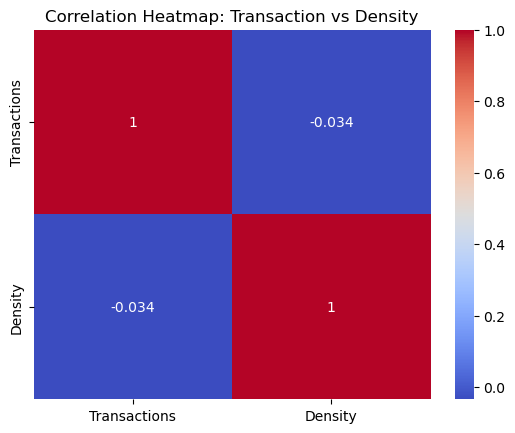

In [ ]:
corr = agg_distTxn_Demo[['Transactions','Density']].corr()
sns.heatmap(data= corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Transaction vs Density')
plt.show()

Conclusion: The value -0.034 signifies that there is almost no linear relationship between Transactions and Density. Changes in population density do not significantly affect number of transaction at the State level.

In [ ]:
# No need of below code
# Correlation between Population and Density at District level

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

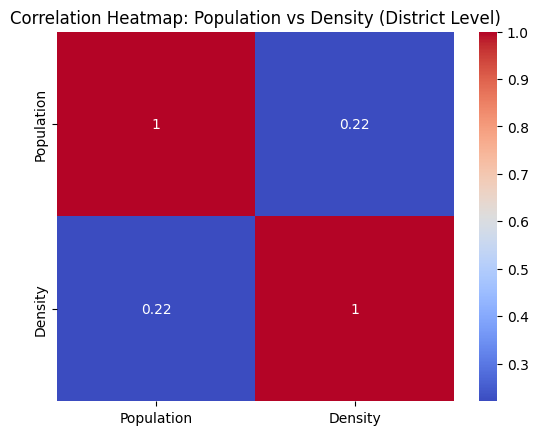

In [12]:
corr_dist = distTxn_Demo[['Population','Density']].corr()
sns.heatmap(data= corr_dist, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Population vs Density (District Level)')
plt.show()

In [ ]:
# Value 0.22 indicates weak positive relationship between Population and Density.
# There is a slight tendency for districts with higher population density to have more transactions, but other factors likely play a significant role as well.

4.3 Average transaction amount per user

In [ ]:
agg_distTxn_Demo4_3 = distTxn_Demo.groupby('State').agg({'Amount (INR)':'sum', 'Registered Users':'sum'}).reset_index()
agg_distTxn_Demo4_3['Avg_TxnAmt_perUser'] = agg_distTxn_Demo4_3['Amount (INR)']/agg_distTxn_Demo4_3['Registered Users']
agg_distTxn_Demo4_3 = agg_distTxn_Demo4_3.sort_values(by = 'Avg_TxnAmt_perUser', ascending = False)
print(agg_distTxn_Demo4_3.head())
print(agg_distTxn_Demo4_3.tail())

             State  Amount (INR)  Registered Users  Avg_TxnAmt_perUser
31       Telangana  4.574246e+12         149224214        30653.509622
1   Andhra Pradesh  3.860292e+12         158007957        24430.998364
15       Karnataka  4.361396e+12         203098564        21474.282206
28       Rajasthan  2.625584e+12         149770064        17530.768707
8            Delhi  1.649942e+12          95374654        17299.587909
                                   State  Amount (INR)  Registered Users  \
12                      Himachal Pradesh  9.786546e+10          13373980   
16                                Kerala  3.729599e+11          51267042   
7   Dadra & Nagar Haveli and Daman & Diu  1.865878e+10           2701112   
32                               Tripura  2.097051e+10           3661575   
18                           Lakshadweep  1.921587e+08             34223   

    Avg_TxnAmt_perUser  
12         7317.601442  
16         7274.846690  
7          6907.815954  
32         5727.1

4.4 Device brand usage ratio

In [ ]:
stateTxn_DevData.shape

(5544, 6)

In [ ]:
stateTxn_DevData.head(2)

,State,Year,Quarter,Brand,Registered Users,Percentage
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392


In [ ]:
stateTxn_Users.shape

(504, 8)

In [ ]:
stateTxn_Users.head(2)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0


In [13]:
df4_4 = pd.merge(stateTxn_DevData,stateTxn_Users, how = 'left', on = ['State', 'Year', 'Quarter'])

In [ ]:
df4_4.head(11)

,State,Year,Quarter,Brand,Registered Users_x,Percentage,Transactions,Amount (INR),ATV (INR),Registered Users_y,App Opens
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392,6658,1.463176e+07,2197.621091,6740,0
2,Andaman & Nicobar Islands,2018,1,Vivo,982,0.145697,6658,1.463176e+07,2197.621091,6740,0
3,Andaman & Nicobar Islands,2018,1,Oppo,501,0.074332,6658,1.463176e+07,2197.621091,6740,0
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,0.049258,6658,1.463176e+07,2197.621091,6740,0
5,Andaman & Nicobar Islands,2018,1,Realme,316,0.046884,6658,1.463176e+07,2197.621091,6740,0
6,Andaman & Nicobar Islands,2018,1,Apple,229,0.033976,6658,1.463176e+07,2197.621091,6740,0
7,Andaman & Nicobar Islands,2018,1,Motorola,226,0.033531,6658,1.463176e+07,2197.621091,6740,0
8,Andaman & Nicobar Islands,2018,1,Lenovo,202,0.029970,6658,1.463176e+07,2197.621091,6740,0
9,Andaman & Nicobar Islands,2018,1,Huawei,158,0.023442,6658,1.463176e+07,2197.621091,6740,0


In [19]:
a = df4_4.groupby(['State','Brand'])['Registered Users_x'].sum().reset_index()
print(a.shape)
# print(a)
b = df4_4.groupby('State')['Registered Users_y'].apply(lambda x: x.unique().sum())
print(b.shape)
# print(b)
c = pd.merge(a,b,how='left',on='State')
print(c.shape)
# print(c)

(448, 3)
(36,)
(448, 4)


In [ ]:
c['Ratio'] = c['Registered Users_x']/c['Registered Users_y']

In [ ]:
c[c['State']=='Andaman & Nicobar Islands']

,State,Brand,Registered Users_x,Registered Users_y,Ratio
0,Andaman & Nicobar Islands,Apple,9334,408396,0.022855
1,Andaman & Nicobar Islands,Huawei,11497,408396,0.028152
2,Andaman & Nicobar Islands,Lenovo,5362,408396,0.013129
3,Andaman & Nicobar Islands,Motorola,9491,408396,0.023240
4,Andaman & Nicobar Islands,OnePlus,15397,408396,0.037701
5,Andaman & Nicobar Islands,Oppo,36007,408396,0.088167
6,Andaman & Nicobar Islands,Others,33630,408396,0.082347
7,Andaman & Nicobar Islands,Realme,22546,408396,0.055206
8,Andaman & Nicobar Islands,Samsung,77065,408396,0.188702
9,Andaman & Nicobar Islands,Tecno,1770,408396,0.004334


In [ ]:
# plt.figure(figsize = (14,7))
# sns.barplot(data = c, x='State' , y='Ratio')
# plt.title('Device Brand Usage Ratio for Each State')
# plt.xlabel('State')
# plt.ylabel('Ratio')
# plt.xticks(rotation = 90)
# plt.show()

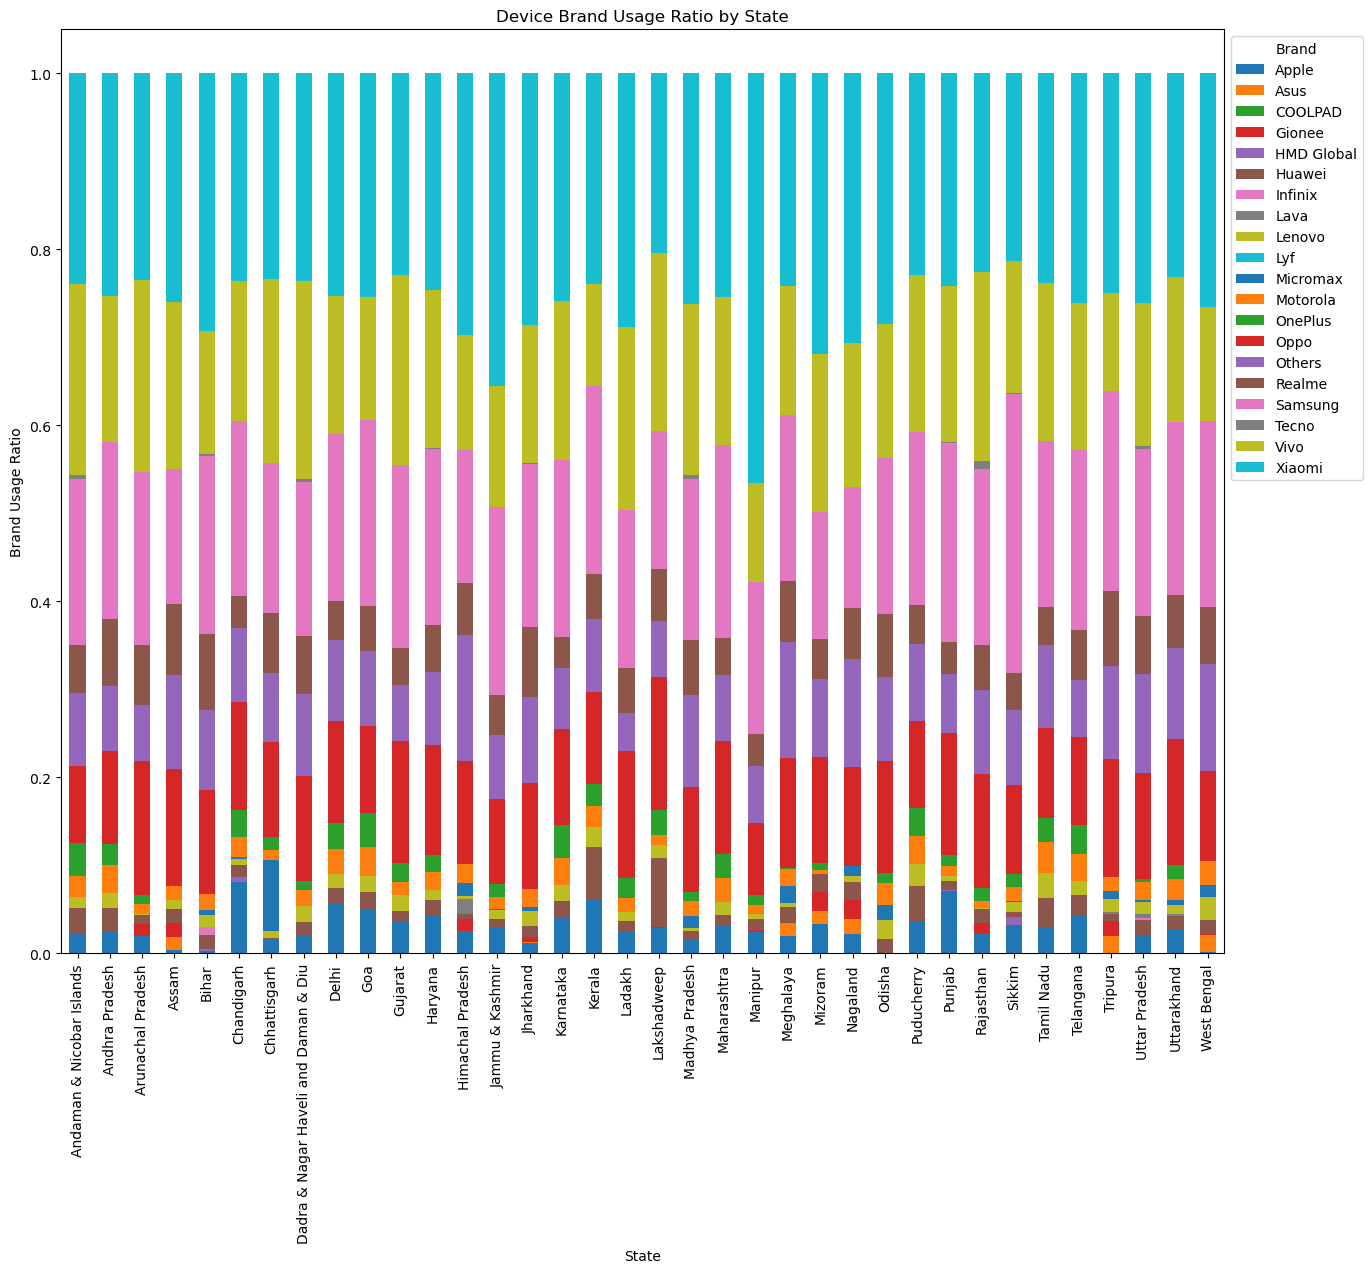

In [ ]:
pivot_df4_4 = c.pivot(index='State',columns='Brand', values = 'Ratio')

pivot_df4_4.plot(kind='bar', stacked=True, figsize=(15,12))
plt.ylabel('Brand Usage Ratio')
plt.title('Device Brand Usage Ratio by State')
plt.legend(title='Brand', bbox_to_anchor=(1,1), loc='upper left')
# plt.tight_layout()
plt.show()

Task 5: Data Visualization

5.1 Plot the total transactions and amount over time for a selected state

In [ ]:
stateTxn_Users.columns

Index(['State', 'Year', 'Quarter', 'Transactions', 'Amount (INR)', 'ATV (INR)',
       'Registered Users', 'App Opens'],
      dtype='object')

In [8]:
stateTxn_Users['Year-Quarter'] = stateTxn_Users['Year'].astype('str') + '-Q' + stateTxn_Users['Quarter'].astype('str')

In [ ]:
stateTxn_Users.columns

Index(['State', 'Year', 'Quarter', 'Transactions', 'Amount (INR)', 'ATV (INR)',
       'Registered Users', 'App Opens', 'Year-Quarter'],
      dtype='object')

In [ ]:
stateTxn_Users[stateTxn_Users['State']=='Maharashtra']

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Year-Quarter
280,Maharashtra,2018,1,16387034,2.171161e+10,1324.926357,6106994,0,2018-Q1
281,Maharashtra,2018,2,22285740,3.635706e+10,1631.404532,8222371,0,2018-Q2
282,Maharashtra,2018,3,31538538,5.226082e+10,1657.046301,10435033,0,2018-Q3
283,Maharashtra,2018,4,46090223,7.951894e+10,1725.288616,13381602,0,2018-Q4
284,Maharashtra,2019,1,75079069,1.114207e+11,1484.044653,16284451,0,2019-Q1
285,Maharashtra,2019,2,101149853,1.532945e+11,1515.518466,18776975,109967705,2019-Q2
286,Maharashtra,2019,3,148735581,1.996175e+11,1342.096527,21313081,439998413,2019-Q3
287,Maharashtra,2019,4,201260620,2.729944e+11,1356.422477,23745297,543654112,2019-Q4
288,Maharashtra,2020,1,238944081,3.199952e+11,1339.205371,26168390,615146568,2020-Q1
289,Maharashtra,2020,2,184790761,2.963595e+11,1603.757220,28765086,506354812,2020-Q2


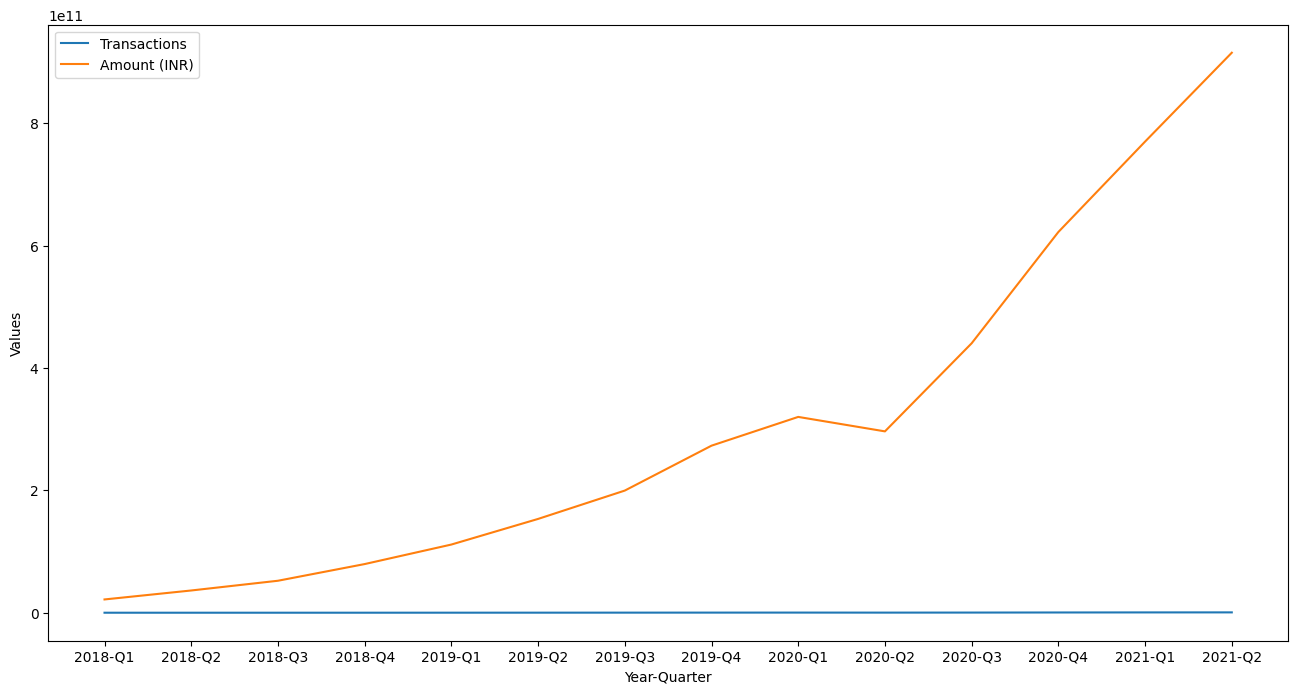

In [9]:
# plt.figure(figsize=(16,8))
# sns.lineplot(data = stateTxn_Users[stateTxn_Users['State']=='Maharashtra'], x='Year-Quarter', y = 'Transactions', label='Transactions')
# sns.lineplot(data = stateTxn_Users[stateTxn_Users['State']=='Maharashtra'], x='Year-Quarter', y = 'Amount (INR)', label='Amount (INR)')
# plt.ylabel('Values')
# plt.legend()
# plt.show()

# This code will not work as the scale of values of Transactions and Amount (INR) are different.

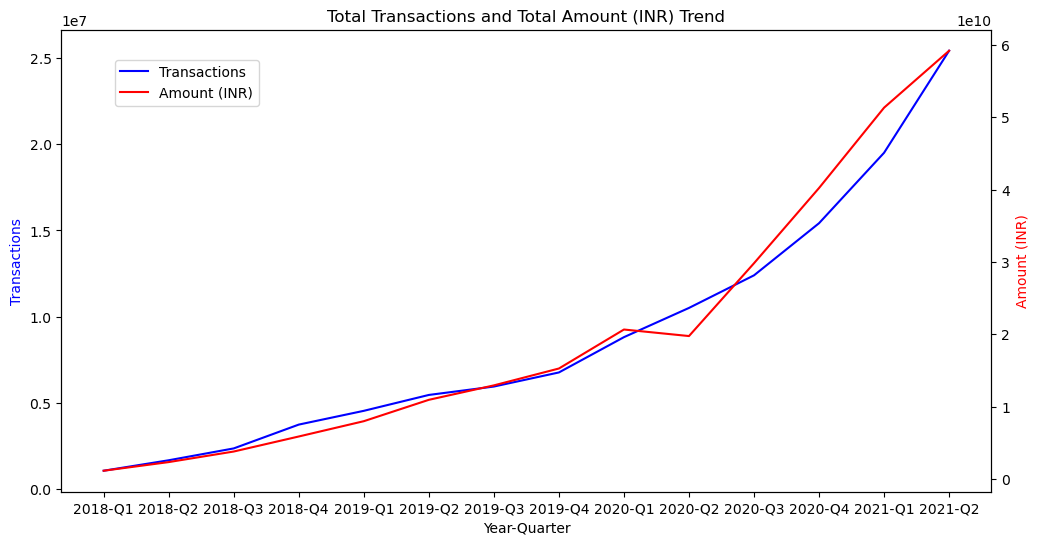

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))
state = 'Assam'
sns.lineplot(data=stateTxn_Users[stateTxn_Users['State'] == state], x='Year-Quarter', y='Transactions', ax=ax1, color='blue', label='Transactions', legend = False)
ax1.set_ylabel('Transactions', color='blue')
ax2 = ax1.twinx()
sns.lineplot(data=stateTxn_Users[stateTxn_Users['State'] == state], x='Year-Quarter', y='Amount (INR)', ax=ax2, color='red', label='Amount (INR)', legend = False)
ax2.set_ylabel('Amount (INR)', color='red')
plt.title('Total Transactions and Total Amount (INR) Trend')
# ax1.get_legend().remove()
# ax2.get_legend().remove()
fig.legend(loc='upper left', bbox_to_anchor=(0.05,0.95), bbox_transform=ax1.transAxes)
plt.show()

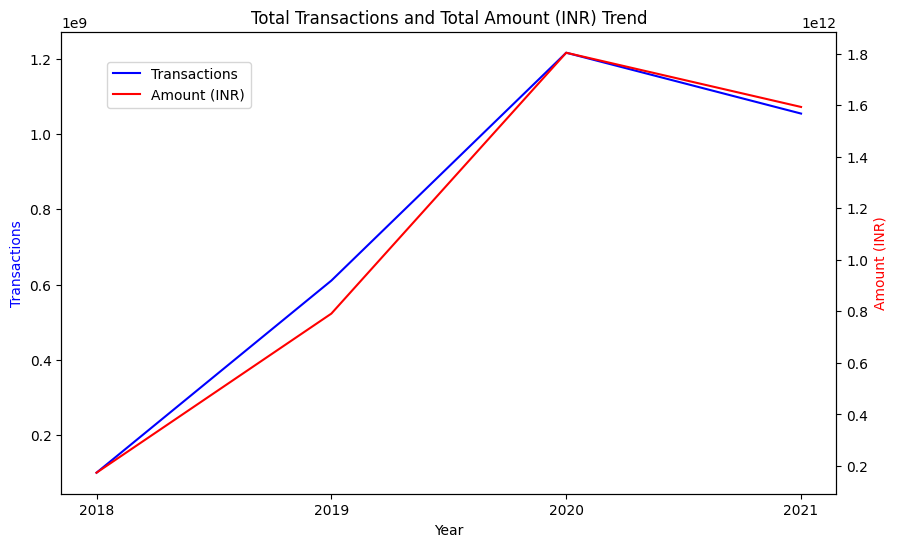

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

agg_stateTxn_Users5_1 = stateTxn_Users.groupby(['State','Year']).agg({'Transactions':'sum','Amount (INR)':'sum'}).reset_index()
fig, ax1 = plt.subplots(figsize=(10, 6))
state = 'Karnataka'
sns.lineplot(data=agg_stateTxn_Users5_1[agg_stateTxn_Users5_1['State'] == state], x='Year', y='Transactions', ax=ax1, color='blue', label='Transactions', legend = False)
ax1.set_ylabel('Transactions', color='blue')
ax2 = ax1.twinx()
sns.lineplot(data=agg_stateTxn_Users5_1[agg_stateTxn_Users5_1['State'] == state], x='Year', y='Amount (INR)', ax=ax2, color='red', label='Amount (INR)', legend = False)
ax2.set_ylabel('Amount (INR)', color='red')
plt.title('Total Transactions and Total Amount (INR) Trend')
# ax1.get_legend().remove()
# ax2.get_legend().remove()
fig.legend(loc='upper left', bbox_to_anchor=(0.05,0.95), bbox_transform=ax1.transAxes)
ax1.set_xticks([2018, 2019, 2020, 2021]) # Set x-axis ticks to specific years
plt.show()

5.2 Create a pie chart showing the distribution of transaction types for a specific quarter

In [13]:
stateTxn_Split['Year-Quarter'] = stateTxn_Split['Year'].astype('str') + '-Q' + stateTxn_Split['Quarter'].astype('str')

In [19]:
state = 'Maharashtra'
year_quarter = '2021-Q2'

filtered_data5_2 = stateTxn_Split[(stateTxn_Split['State'] == state) & (stateTxn_Split['Year-Quarter']== year_quarter)]
grouped_filtered_data5_2 = filtered_data5_2.groupby('Transaction Type')['Transactions'].sum().reset_index()
print(grouped_filtered_data5_2)

           Transaction Type  Transactions
0        Financial Services        504252
1         Merchant payments     247194293
2                    Others       1094842
3     Peer-to-peer payments     228551961
4  Recharge & bill payments      96271138


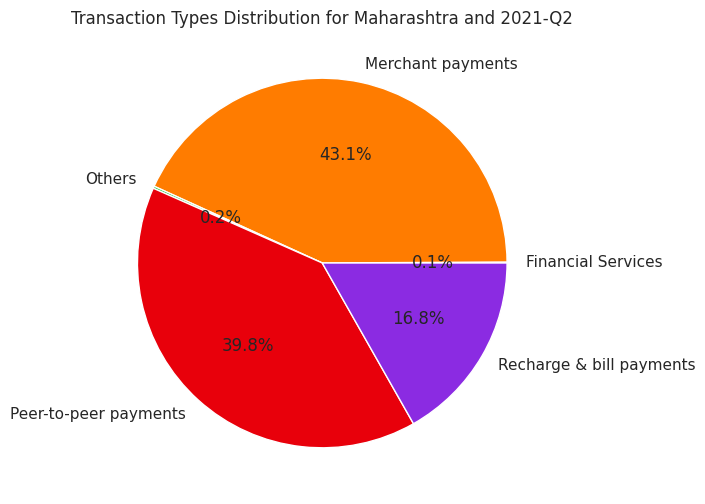

In [27]:
sns.set_theme(style='dark')
colors = sns.color_palette('bright')[0:len(grouped_filtered_data5_2['Transaction Type'])]

plt.figure(figsize = (6,6))
plt.pie(data = grouped_filtered_data5_2, x = 'Transactions', labels='Transaction Type', autopct='%1.1f%%', colors=colors)
plt.title(f'Transaction Types Distribution for {state} and {year_quarter}')
# plt.axis('equal')
plt.ylabel('')
plt.show()

In [12]:
state = 'Delhi'

filtered_data5_2_1 = stateTxn_Split[stateTxn_Split['State'] == state]
grouped_filtered_data5_2_1 = filtered_data5_2_1.groupby('Transaction Type')['Transactions'].sum().reset_index()
print(grouped_filtered_data5_2_1)

           Transaction Type  Transactions
0        Financial Services       2014833
1         Merchant payments     414408596
2                    Others      21472945
3     Peer-to-peer payments     404635052
4  Recharge & bill payments     168499698


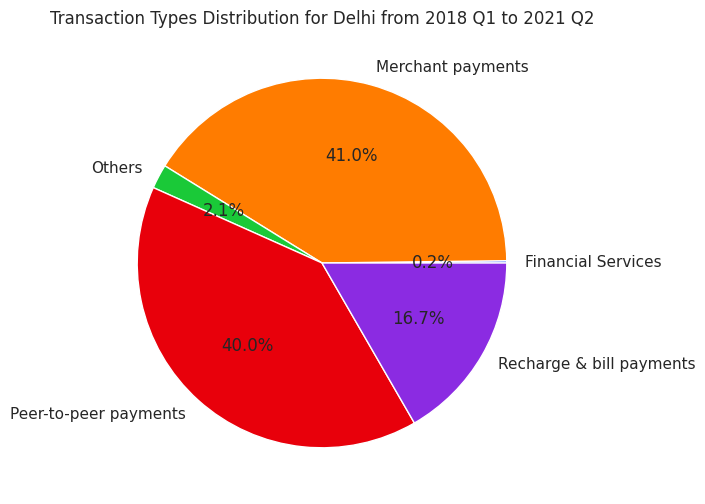

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='dark')
colors = sns.color_palette('bright')[0:len(grouped_filtered_data5_2_1['Transaction Type'])]

plt.figure(figsize = (6,6))
plt.pie(data = grouped_filtered_data5_2_1, x = 'Transactions', labels='Transaction Type', autopct='%1.1f%%', colors=colors)
plt.title(f'Transaction Types Distribution for {state} from 2018 Q1 to 2021 Q2')
# plt.axis('equal')
plt.ylabel('')
plt.show()

5.3 Visualize the population density of districts in a selected state

In [ ]:
distTxn_Demo.head(2)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Year-Quarter,Headquarters,Population,Area (sq km),Density,Alternate Name
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0,2018-Q1,Car Nicobar,36842.0,1841.0,20.0,Nicobars
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0,2018-Q1,Mayabunder,105597.0,3736.0,28.0,North and Middle Andaman


In [33]:
selected_state = 'West Bengal'
filtered_distTxn_Demo = distTxn_Demo[distTxn_Demo['State'] == selected_state]
# distTxn_Demo[(distTxn_Demo['State'] == selected_state)&(distTxn_Demo['District']=='Alipurduar')]
agg_distTxn_Demo = filtered_distTxn_Demo.groupby(['State','District'])['Density'].apply(lambda x: x.unique().sum()).reset_index()
print(agg_distTxn_Demo.head(2))

         State    District  Density
0  West Bengal  Alipurduar    479.0
1  West Bengal     Bankura    523.0


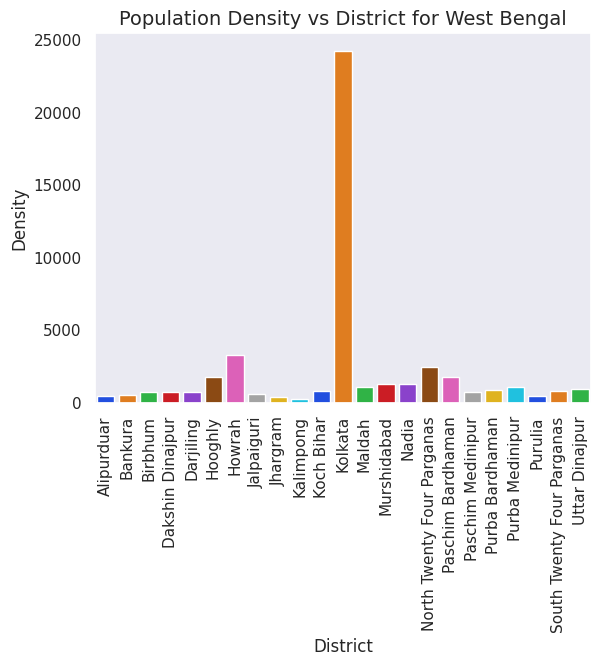

In [35]:
sns.barplot(data=agg_distTxn_Demo,x='District',y='Density', hue ='District', palette='bright')
plt.title(f'Population Density vs District for {selected_state}', fontsize=14)
plt.xlabel('District')
plt.ylabel('Density')
plt.xticks(rotation=90)
plt.show()

## Summary of Findings and Conclusions

### Task 1: Data Loading and Understanding

*   **Missing Values:** Detected in `stateTxn_Users` (1 in 'Amount (INR)') and `distTxn_Users` (28 in 'Code', 4 in 'ATV (INR)'). These represent minor percentages of the total data.
*   **Geographical Coverage:** The datasets cover 36 states and 723 unique districts across India.
*   **State with Most Districts:** 'Uttar Pradesh' has the highest number of districts recorded in the dataset.


### Task 2: Exploratory Data Analysis (EDA)

*   **Transaction Volume:** 'Karnataka', 'Maharashtra', and 'Telangana' are the top states by transaction volume and total amount.
*   **Lowest Transaction Volume:** 'Lakshadweep', 'Andaman & Nicobar Islands', and 'Ladakh' show the lowest transaction volumes.
*   **Most Common Transaction Type:** 'Recharge & bill payments' consistently appears as the most common transaction type across various states and quarters, including 'Andaman & Nicobar Islands' and 'Maharashtra' in 2021-Q2.
*   **Device Brands:** 'Xiaomi' is identified as the device brand with the highest number of registered users in many states, including 'Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', and 'Bihar'.
*   **District Population:** 'North 24 Parganas' (West Bengal), 'Bangalore Urban' (Karnataka), and 'Pune' (Maharashtra) are the most populous districts in their respective states.
*   **Average Transaction Value (ATV):** 'Ladakh', 'Andaman & Nicobar Islands', and 'Mizoram' have the highest ATVs, while 'West Bengal', 'Tripura', and 'Delhi' have the lowest.
      * **what is the reason of these ATV values??**
  High ATV in remote or tourist-heavy regions might be due to higher costs, tourism spending, or fewer, larger purchases. Conversely, low ATV in densely populated states can be attributed to the high volume of small-value, everyday transactions driven by widespread digital payment adoption and competitive pricing.
*   **App Usage Trends:** App Opens data for 'West Bengal' shows a general increasing trend over time, especially from 2019-Q2 onwards.
    * **how can the app open value be 0 if transactions, amount and atv are non-zero ???** The transaction data seems valid, the 'App Opens' data for these specific periods should be handled carefully, likely indicating a data collection gap rather than actual zero app activity.
*   **District Code Mapping:** A unique mapping between district names and their codes has been created and saved.


### Task 3: Data Quality Checks

*   **Consistency Check:** A comparison between aggregated district-level transaction data (`distTxn_Users` aggregated to state level) and the state-level transaction data (`stateTxn_Users`) revealed minor discrepancies in 'Amount (INR)' and more significant differences in 'ATV (INR)'. This suggests some inconsistencies in how ATV is calculated or recorded between the district and state datasets, or due to aggregation methods.


### Task 4: Data Merging and Advanced Analysis

*   **User-to-Population Ratio:** The ratio of registered users to population varies significantly across states, indicating differences in digital payment adoption or PhonePe penetration.
    * **what does high value of this ratio means ??**
  A high ratio of registered users to population generally indicates strong digital adoption and PhonePe penetration. It also points to effective marketing, good digital infrastructure, and greater financial inclusion within that state. For specific cases like Delhi, an unusually high ratio could be explained by a large transient population (migrant workers, students) not fully captured in official population counts, rather than simply data error.
*   **Population Density vs. Transaction Volume:** At the state level, there is almost no linear relationship between population density and transaction volume (correlation of -0.034). This suggests that high population density alone does not directly drive higher transaction volumes at the state aggregate level.
*   **Population vs. Density (District Level):** A weak positive correlation (0.22) was observed between population and density at the district level. This implies that while more populous districts tend to be denser, other factors influence this relationship.
**I think there is no need for this finding**
*   **Average Transaction Amount Per User:** 'Telangana', 'Andhra Pradesh', and 'Karnataka' show the highest average transaction amounts per user, suggesting higher-value transactions or more active users in these states. 'Lakshadweep' and 'Tripura' have the lowest.
*   **Device Brand Usage Ratio:** The analysis shows varying penetration of different device brands across states, with a clear dominance of certain brands (e.g., Xiaomi, Samsung, Vivo) in terms of registered users.


### Task 5: Data Visualization

*   **Transaction and Amount Trends:** Line plots effectively visualize the trends of total transactions and total amount (INR) over time for selected states (e.g., Karnataka), often showing parallel growth.
*   **Transaction Type Distribution:** Pie charts clearly illustrate the distribution of transaction types for specific states and quarters, highlighting the most dominant transaction categories.
*   **Population Density by District:** Bar plots provide a clear comparison of population density across districts within a chosen state, enabling quick identification of denser areas.

### Overall Conclusion

This analysis provides a comprehensive overview of PhonePe's transaction and user data across different states and districts in India. Key insights include the dominance of certain states in transaction volume, the prevalence of 'Recharge & bill payments', the significant market share of specific mobile device brands, and the lack of a strong direct correlation between state-level population density and transaction volume. The identified data inconsistencies, particularly in ATV calculations, highlight areas for potential data cleaning or reconciliation to ensure accuracy in future analyses. These findings can inform strategic decisions related to market penetration, service offerings, and targeted marketing efforts.